In [ ]:
import warnings

from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")
import torch

import pandas as pd
import numpy as np
import scanpy as sc
import os
import yaml
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['R_HOME'] = '/home/anaconda3/envs/SpaDAR/lib/R'
os.environ['R_USER'] = '/home/anaconda3/envs/SpaDAR/lib/site-packages/rpy2'
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.decomposition import PCA

In [ ]:
import os
import sys

current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

try:
    import SpaDAR as TOOLS
except ModuleNotFoundError:
    print("❌ 依然找不到 SpaDAR，请确认当前工作目录是否正确。")
    print(f"当前搜索路径: {current_dir}")

section_ids = ['E9.5_E1S1', 'E10.5_E2S1', 'E11.5_E1S1']
def load_data(k_cutoff, n_top_genes):
    Batch_list = []
    for slice_id, proj_name in enumerate(section_ids):
        adata = sc.read_h5ad(os.path.join(r"/home/SpaDAR/data_zip/Stereoseq Mouse embryo/" + proj_name + ".MOSTA.h5ad"))
        adata.var_names_make_unique()
        adata.obs_names = [x + '_' + proj_name for x in adata.obs_names]
        ##### Load layer_guess label, if have
        adata.obs['layer_guess'] = adata.obs['annotation']
        adata.obs['slice_id'] = slice_id

        adata.layers['count'] = adata.X
        sc.pp.filter_genes(adata, min_cells=50)
        sc.pp.filter_genes(adata, min_counts=10)
        sc.pp.normalize_total(adata, target_sum=1e6)
        sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=n_top_genes)
        adata = adata[:, adata.var['highly_variable'] == True]
        sc.pp.scale(adata)
        adata = adata[:, adata.var['highly_variable']]
        Batch_list.append(adata)

    adata, edge_index = TOOLS.graph_construction3D(Batch_list, section_ids=section_ids, k_cutoff=k_cutoff, rad_cutoff=None, mode='KNN', slice_dist_micron=[100, 100], coor_key='spatial')
    adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
    adata.obsm['X_pca'] = adata_X
    return adata, edge_index

In [ ]:
adata, edge_index = load_data(8, 5000)

Start building a graph...
Radius for graph connection is 1.5000.
The graph contains 356248 edges, 44531 cells.
8.0000 neighbors per cell on average.


In [4]:
with open('../Config/ME3.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

In [ ]:
num_clusters = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = TOOLS.SC_BC_pipeline(adata, edge_index=edge_index, num_clusters=num_clusters, device=device, config=config, imputation=False)
# %%
net.trian()
# %%
enc_rep, recon = net.process()
adata.obsm['latent'] = enc_rep
adata.obsm['recon'] = recon
# %%

Epoch 299 total loss=1.609 recon loss=0.727 mean loss=0.342 tri loss=1.343: 100%|██████████| 300/300 [03:38<00:00,  1.37it/s]


In [6]:
# %%
clusType = 'mclust'
adata.obs[clusType] = TOOLS.clustering(z=enc_rep, n_clust=num_clusters, num_seed=1, method=clusType)
sub_adata = adata[~pd.isnull(adata.obs['layer_guess'])]
ARI = ari_score(sub_adata.obs['layer_guess'], sub_adata.obs[clusType])

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


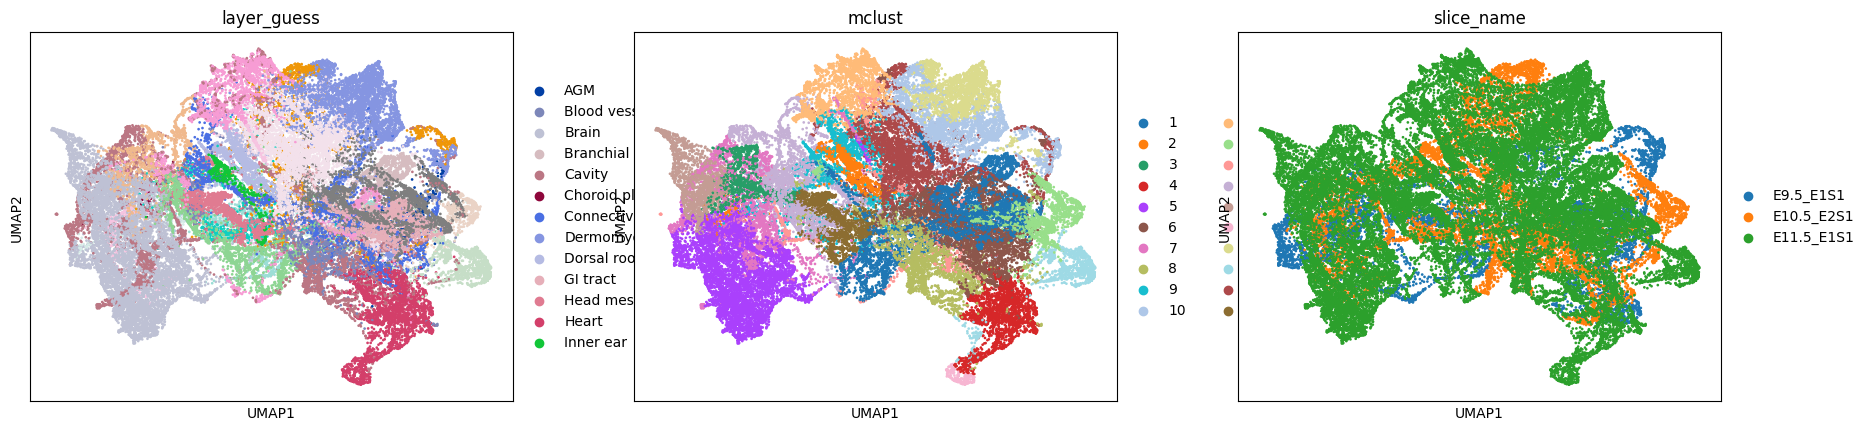

In [7]:
sc.pp.neighbors(adata, use_rep='latent', metric='cosine')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['layer_guess', 'mclust', 'slice_name'], show=True, size=15, save=False)

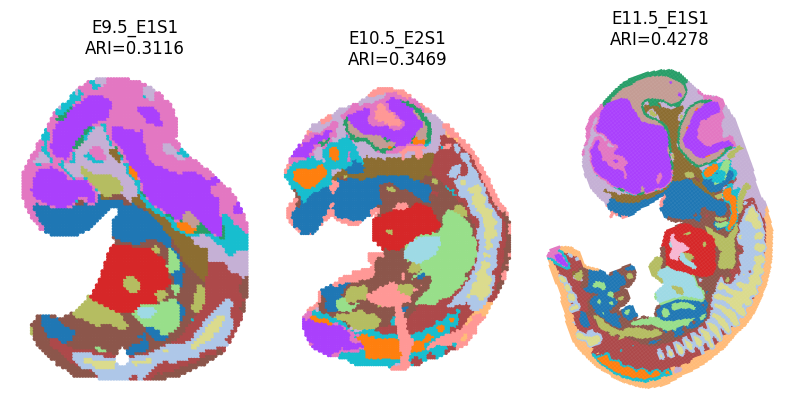

In [8]:
spot_size = 1.5
title_size = 12
fig, ax = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
for idx, name in enumerate(section_ids):
    sub_adata = adata[adata.obs['slice_name'] == name]
    sub_adata_tmp = sub_adata[~pd.isnull(sub_adata.obs['layer_guess'])]
    ARI = ari_score(sub_adata_tmp.obs['layer_guess'], sub_adata_tmp.obs["mclust"])
    _sc_ = sc.pl.spatial(sub_adata, img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[idx], frameon=False,
                      spot_size=spot_size)
    _sc_[0].set_title(name + "\nARI=" + str(round(ARI, 4)), size=title_size)
plt.show()

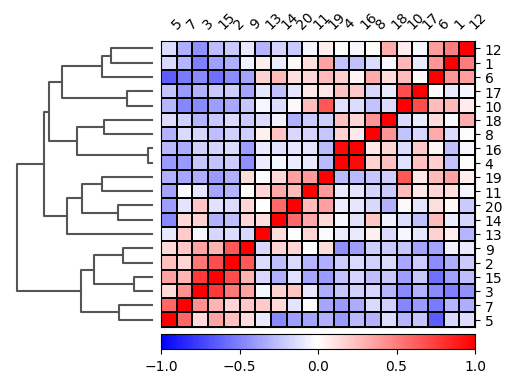

In [ ]:
sc.pl.correlation_matrix(adata, 'mclust', figsize=(6, 4), show=False)
plt.tight_layout()
plt.show()

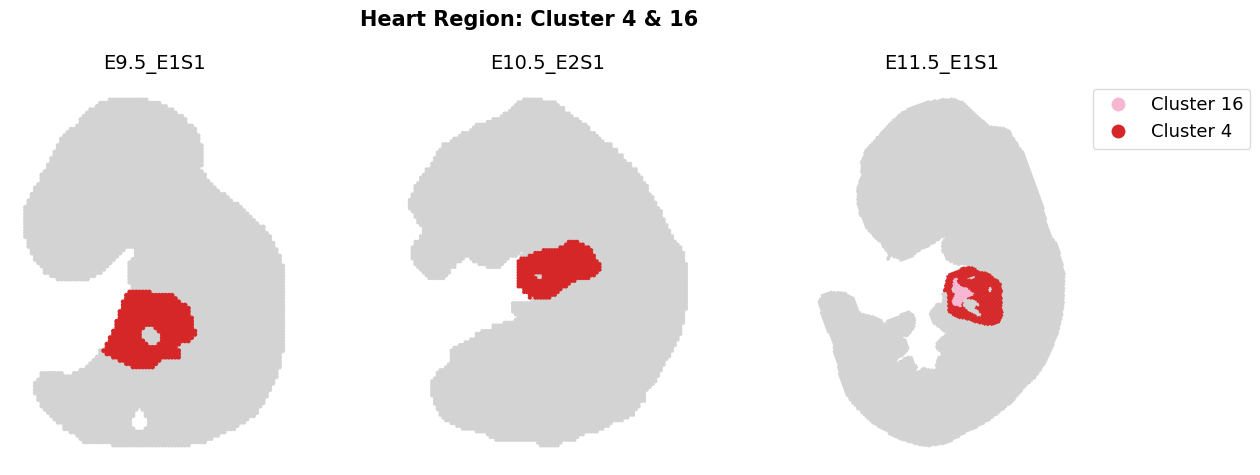

In [ ]:
from matplotlib.lines import Line2D

target_clusters = ['16', '4']
spot_size = 1.5
title_size = 14

if 'mclust_colors' not in adata.uns:
    sc.pl._utils._set_default_colors_for_categorical_obs(adata, 'mclust')
color_dict = dict(zip(adata.obs['mclust'].cat.categories, adata.uns['mclust_colors']))

fig, axes = plt.subplots(1, len(section_ids), figsize=(5 * len(section_ids), 5),
                          gridspec_kw={'wspace': 0.05})
if len(section_ids) == 1:
    axes = [axes]

for idx, name in enumerate(section_ids):
    sub_adata = adata[adata.obs['slice_name'] == name]
    sc.pl.spatial(
        sub_adata, color='mclust', groups=target_clusters,
        img_key=None, legend_loc=None, show=False,
        ax=axes[idx], frameon=False, spot_size=spot_size
    )
    axes[idx].set_title(name, size=title_size, pad=8)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

custom_lines = [Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}',
                        markerfacecolor=color_dict[c], markersize=11)
                for c in target_clusters if c in color_dict]
axes[-1].legend(handles=custom_lines, loc='upper left',
                bbox_to_anchor=(1.02, 1), frameon=True, fontsize=13, edgecolor='lightgray')

plt.suptitle('Heart Region: Cluster 4 & 16', fontsize=15, fontweight='bold', y=1.02)
plt.show()

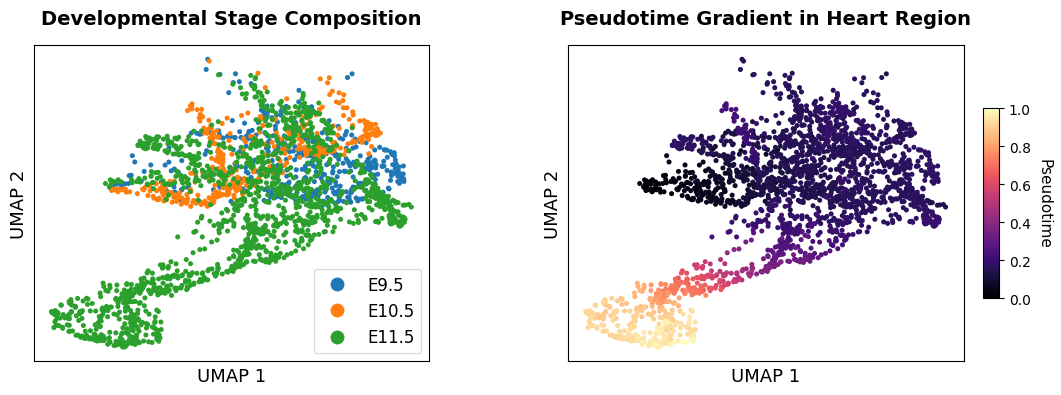

In [ ]:
import scipy.sparse as sp
from matplotlib.lines import Line2D

target_clusters = ['16', '4']

adata.obs['is_heart'] = adata.obs['mclust'].astype(str).apply(
    lambda x: 'Target' if x in target_clusters else 'Rest'
).astype('category')

adata_heart = adata[adata.obs['is_heart'] == 'Target'].copy()

stage_dict = {'E9.5_E1S1': 'E9.5', 'E10.5_E2S1': 'E10.5', 'E11.5_E1S1': 'E11.5'}
adata_heart.obs['Stage'] = adata_heart.obs['slice_name'].map(stage_dict).astype('category')
if adata_heart.obs['Stage'].isna().any():
    adata_heart.obs['Stage'] = adata_heart.obs['slice_name'].astype('category')
else:
    available_stages = [s for s in ['E9.5', 'E10.5', 'E11.5'] if s in adata_heart.obs['Stage'].cat.categories]
    adata_heart.obs['Stage'] = adata_heart.obs['Stage'].cat.reorder_categories(available_stages)

sc.pp.neighbors(adata_heart, n_neighbors=25, use_rep='latent', metric='cosine')
sc.tl.diffmap(adata_heart)
root_idx = np.argmin(adata_heart.obsm['X_diffmap'][:, 1])
adata_heart.uns['iroot'] = root_idx
sc.tl.dpt(adata_heart)

adata_heart.obs['Phase'] = 'Earlier stage'
adata_heart.obs.loc[adata_heart.obs['dpt_pseudotime'] > 0.8, 'Phase'] = 'Late phase'
adata_heart.obs['Phase'] = adata_heart.obs['Phase'].astype('category')

stage_colors_dict = {'E9.5': '#1f77b4', 'E10.5': '#ff7f0e', 'E11.5': '#2ca02c'}
adata_heart.uns['Stage_colors'] = [stage_colors_dict[cat] for cat in adata_heart.obs['Stage'].cat.categories]

fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'wspace': 0.35})

sc.pl.umap(adata_heart, color='Stage', ax=axs[0], show=False,
           title='', frameon=True, legend_loc=None)
axs[0].set_title('Developmental Stage Composition', fontsize=14, fontweight='bold', pad=15)
custom_lines = [Line2D([0], [0], marker='o', color='w', label=s, markerfacecolor=c, markersize=11)
                for s, c in zip(adata_heart.obs['Stage'].cat.categories, adata_heart.uns['Stage_colors'])]
axs[0].legend(handles=custom_lines, loc='lower right', frameon=True, fontsize=12, edgecolor='lightgray')
axs[0].set_xlabel('UMAP 1', fontsize=13, fontweight='normal')
axs[0].set_ylabel('UMAP 2', fontsize=13, fontweight='normal')
axs[0].set_box_aspect(0.8)

sc.pl.umap(adata_heart, color='dpt_pseudotime', color_map='magma', ax=axs[1], show=False,
           title='', frameon=True, colorbar_loc=None)
axs[1].set_title('Pseudotime Gradient in Heart Region', fontsize=14, fontweight='bold', pad=15)
axs[1].set_xlabel('UMAP 1', fontsize=13, fontweight='normal')
axs[1].set_ylabel('UMAP 2', fontsize=13, fontweight='normal')
axs[1].set_box_aspect(0.8)
cax1 = axs[1].inset_axes([1.05, 0.2, 0.04, 0.6])
cbar1 = fig.colorbar(axs[1].collections[0], cax=cax1)
cbar1.set_label('Pseudotime', rotation=270, labelpad=15, fontsize=11)

plt.show()